<a href="https://colab.research.google.com/github/andreagc8/RiesgosFinancieros/blob/master/ValuacionPortafolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Valuación de Instrumentos Gubernamentales de Deuda

**Riesgos Financieros — 2027-1**

Este cuaderno es una introducción práctica a la **valuación de deuda gubernamental mexicana** usando curvas de tasas de interés. Vamos a valuar tres instrumentos muy comunes en el mercado local:

| Instrumento | ¿Qué es? | ¿Cómo paga? |
|---|---|---|
| **CETES** (bono cupón cero) | Título de deuda de corto plazo | Un solo pago al vencimiento (el valor nominal). No paga intereses periódicos. |
| **Bono M** | Bono de tasa fija a mediano/largo plazo | Cupones fijos, normalmente semestrales, más el nominal al vencimiento. |
| **Bonde D** | Bono de tasa flotante (revisable) | Cupones cada 28 días, referenciados a la tasa de fondeo bancario. |

### 🗺️ Ruta del cuaderno
1. **Marco teórico** — curvas cupón cero, curvas *yield* e interpolación de tasas.
2. **Parámetros** — cambia la fecha de valuación, el método de interpolación y las características de cada bono usando los **campos de formulario** (el panel a la derecha de cada celda, o el ícono ⋮ → *Mostrar código* para ver el Python).
3. **Carga de datos** — se descargan curvas de mercado históricas del repositorio del curso.
4. **Visualización** — cómo luce la curva de tasas el día de valuación.
5. **Valuación** — CETES, Bonos M (dos métodos) y Bondes D, paso a paso, con la fórmula matemática antes de cada bloque de código.
6. **Resumen** — tabla y gráfica comparativa de resultados.

> 💡 **Tip:** en Colab, las celdas con formulario muestran solo los campos de entrada; el código detrás sigue ahí, solo está colapsado. Usa el menú ⋮ de la celda (o *Ver → Formularios → Mostrar/ocultar código*) para revisarlo o editarlo directamente.

**Cómo usarlo:** la primera vez, ejecuta todo con *Entorno de ejecución → Ejecutar todas*. Después, cambia cualquier campo de formulario y vuelve a ejecutar el cuaderno desde esa celda hacia abajo para ver cómo cambian los resultados.


In [3]:
# @title 📦 Clonar el repositorio del curso (datos e insumos) { display-mode: "form" }
# Descarga la versión más reciente del repositorio a la máquina virtual de Colab.
# Ahí viven los archivos .txt con las curvas de tasas históricas que usaremos
# para interpolar y valuar los bonos.
!rm -rf RiesgosFinancieros
!git clone "https://github.com/andreagc8/RiesgosFinancieros/"


Cloning into 'RiesgosFinancieros'...
remote: Enumerating objects: 1370, done.
remote: Counting objects: 100% (163/163), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 1370 (delta 118), reused 68 (delta 68), pack-reused 1207 (from 2)
Receiving objects: 100% (1370/1370), 73.17 MiB | 18.60 MiB/s, done.
Resolving deltas: 100% (852/852), done.
Updating files: 100% (475/475), done.


## 🧮 Marco teórico: curvas de tasas de interés

Para valuar cualquier instrumento de deuda necesitamos **traer a valor presente** los flujos futuros que promete pagar. Para eso usamos una **curva de tasas de interés**, que nos dice cuál es la tasa adecuada para descontar un flujo que ocurre dentro de $p$ días.

En este cuaderno usamos dos tipos de curva, construidas con datos de mercado:

- **Curva cupón cero** (`tasa_guber.txt`): tasas de descuento "puras". Se usa para descontar flujo por flujo (método de cupón cero).
- **Curva *yield*** (`tasa_yield.txt`): la tasa interna de retorno (TIR) de mercado de un bono cuponado con esas características. Se usa para valuar de un solo golpe con la fórmula de anualidad de un bono.

### El problema de la interpolación

Las curvas de mercado solo traen tasas para ciertos **plazos fijos** (nodos: 1, 7, 30, 90, 180, 270, 360... días), pero nuestros bonos vencen o pagan cupones en plazos que caen **entre** esos nodos. Hay que **interpolar**. El cuaderno ofrece dos métodos, elegibles con un campo de formulario:

1. **Interpolación lineal** — traza una línea recta entre dos nodos consecutivos y lee el valor sobre esa recta. Simple, pero no es consistente con cómo se componen las tasas en el tiempo.
2. **Tasa alambrada** *(la que usa el mercado mexicano)* — en vez de interpolar la tasa directamente, se interpola de forma que las **tasas forward implícitas** entre nodos sean consistentes. Si $t_c$ y $t_l$ son las tasas de los nodos que rodean al plazo $p$ (entre $p_i$ y $p_{i+1}$), la tasa interpolada resuelve:

$$ t_{p} = \left[ \left( \frac{1+t_l \cdot p_{i+1}/360}{1+t_c \cdot p_i/360} \right)^{\frac{p-p_i}{p_{i+1}-p_i}} \cdot \left(1+t_c \cdot \frac{p_i}{360}\right) - 1\right] \cdot \frac{360}{p}$$

Esto es exactamente lo que hace la función `talamb()` de abajo. Fuera del rango de nodos, ambos métodos simplemente sostienen el valor del nodo más cercano (no extrapolan).

> 🔎 **Para explorar:** más adelante podrás cambiar el método de interpolación con un campo de formulario y comparar cómo cambian los resultados de valuación.


# 🔧 Funciones auxiliares

In [4]:
# @title Función talamb(): interpolación por "tasa alambrada" { display-mode: "both" }
import numpy as np

def talamb(nodos, curva, plazos):
    """
    Interpola tasas de interés de forma consistente con las tasas forward
    implícitas entre nodos (método "tasa alambrada", estándar del mercado
    mexicano para curvas gubernamentales).

    Parámetros
    ----------
    nodos  : plazos (en días) donde conocemos la tasa de la curva.
    curva  : tasas de interés observadas en cada nodo.
    plazos : plazos (en días) donde queremos conocer la tasa interpolada
             (por ejemplo, los vencimientos/cupones de nuestros bonos).

    Regresa
    -------
    Un arreglo con la tasa interpolada para cada elemento de `plazos`.
    Fuera del rango de `nodos` se sostiene el valor del nodo más cercano
    (no se extrapola).
    """
    nodos = nodos.flatten()
    curva = curva.flatten()
    plazos = plazos.flatten()

    # Aseguramos que los nodos estén ordenados para np.interp
    sorted_indices = np.argsort(nodos)
    nodos_sorted = nodos[sorted_indices]
    curva_sorted = curva[sorted_indices]

    # Índices del nodo inferior para cada plazo a interpolar
    indices = np.searchsorted(nodos_sorted, plazos) - 1
    indices[indices < 0] = 0
    indices[indices >= len(nodos_sorted) - 1] = len(nodos_sorted) - 2

    nodos_i = nodos_sorted[indices]
    nodos_i_plus_1 = nodos_sorted[indices + 1]
    TC_interp = curva_sorted[indices]
    TL_interp = curva_sorted[indices + 1]

    # Tasa forward-consistente entre los dos nodos que rodean al plazo
    TF = np.where(plazos < nodos_sorted[0], curva_sorted[0],
             np.where(plazos > nodos_sorted[-1], curva_sorted[-1],
                      ((((1 + TL_interp * nodos_i_plus_1 / 360) / (1 + TC_interp * nodos_i / 360)) **
                        ((plazos - nodos_i) / (nodos_i_plus_1 - nodos_i)) *
                        (1 + TC_interp * nodos_i / 360)) - 1) * 360 / plazos))

    return TF


# 🎛️ Parámetros de valuación

Aquí definimos **todo lo necesario para valuar cada instrumento**: la fecha de valuación, el método de interpolación, y las características de cada bono (plazos, tasas cupón, número de contratos y valor nominal).

Cada bloque está en una **celda de formulario** 📋 — no necesitas tocar código para experimentar, solo cambia los valores en el panel de la derecha y vuelve a ejecutar el cuaderno desde ahí hacia abajo. (Para ver/editar el Python directamente: menú ⋮ de la celda → *Mostrar código*.)

Cada bono se define como un **vector de 5 posiciones de ejemplo**: puedes pensarlo como una pequeña cartera con 5 títulos del mismo tipo pero distinto plazo, algunas posiciones "largas" (compradas) y otras "cortas" (vendidas, con signo negativo).


In [5]:
# @title ⚙️ Parámetros generales { display-mode: "form" }
import numpy as np
from datetime import datetime, timedelta

fecha_valuacion = '2023-03-10'  # @param {type:"date"}
fval = datetime.strptime(fecha_valuacion.replace('-', ''), "%Y%m%d")  # Fecha de valuación

metodo_interpolacion = "Tasa alambrada"  # @param ["Interpolaci\u00F3n lineal", "Tasa alambrada"]
# La "tasa alambrada" es el método usado en el mercado mexicano (ver Marco Te\u00f3rico):
# interpola de forma consistente con las tasas forward impl\u00edcitas entre nodos.
itpl = 0 if metodo_interpolacion == "Interpolaci\u00F3n lineal" else 1

print(f"Fecha de valuaci\u00f3n elegida: {fval:%d/%m/%Y}")
print(f"M\u00e9todo de interpolaci\u00f3n: {metodo_interpolacion} (itpl = {itpl})")


Fecha de valuación elegida: 10/03/2023
Método de interpolación: Tasa alambrada (itpl = 1)


In [6]:
# @title 🧾 Parámetros — CETES (bono cupón cero) { display-mode: "form" }
# Archivo con la curva cupón cero histórica (nodos en columnas, fechas en filas)
base = "RiesgosFinancieros/2022-1/Insumos/tasa_guber.txt" # @param {type:"string"}

plazos_bcc = [37, 40, 55, 120, 180]  # @param {type:"raw"}
contratos_bcc = [22000, -29000, 29000, -46000, 10000]  # @param {type:"raw"}
nominal_bcc = 10  # @param {type:"number"}

plazos_bcc = np.array(plazos_bcc)        # Plazo (d\u00edas) al vencimiento de cada t\u00edtulo
contratos_bcc = np.array(contratos_bcc)  # N\u00famero de contratos (posici\u00f3n; negativo = corto)


In [7]:
# @title 🧾 Parámetros — Bono M (tasa fija) { display-mode: "form" }
# Curva cupón cero y curva yield históricas para valuar el Bono M
btasadesc_bm = "RiesgosFinancieros/2022-1/Insumos/tasa_guber.txt" # @param {type:"string"}
btasayield_bm = "RiesgosFinancieros/2022-1/Insumos/tasa_yield.txt" # @param {type:"string"}

tfcupon_bm = [0.065, 0.0675, 0.07, 0.075, 0.078]  # @param {type:"raw"}
plazos_bm = [378, 405, 550, 1200, 1800]  # @param {type:"raw"}
plazocupon_bm = [182, 182, 182, 182, 182]  # @param {type:"raw"}
contratos_bm = [22000, -29000, 29000, -46000, 10000]  # @param {type:"raw"}
nominal_bm = 100  # @param {type:"number"}

tfcupon_bm = np.array(tfcupon_bm)        # Tasa cup\u00f3n fija de cada bono
plazos_bm = np.array(plazos_bm)          # Plazo (d\u00edas) al vencimiento
plazocupon_bm = np.array(plazocupon_bm)  # Periodicidad del cup\u00f3n (d\u00edas)
contratos_bm = np.array(contratos_bm)    # N\u00famero de contratos (posici\u00f3n)


In [8]:
# @title 🧾 Parámetros — Bonde D (tasa flotante) { display-mode: "form" }
# Curva de sobretasa/spread y serie histórica de la tasa de fondeo bancario
btasadescst = "RiesgosFinancieros/2024-1/Tarea/tasa_guber_st.txt" # @param {type:"string"}
btasafondeo = "RiesgosFinancieros/2024-1/Tarea/tfondeo.txt" # @param {type:"string"}

plazos_bdm = [358, 405, 550, 1200, 1800]  # @param {type:"raw"}
plazocupon_bdm = [28, 28, 28, 28, 28]  # @param {type:"raw"}
contratos_bdm = [220, -290, 290, -460, 100]  # @param {type:"raw"}
nominal_bdm = 100  # @param {type:"number"}

plazos_bdm = np.array(plazos_bdm)
plazocupon_bdm = np.array(plazocupon_bdm)
contratos_bdm = np.array(contratos_bdm)


# 📥 Carga de datos

Con los parámetros ya definidos, toca **leer las curvas de tasas** desde los archivos del repositorio y dejarlas listas para interpolar:

- `tasa_guber.txt` → curva cupón cero (CETES y Bono M).
- `tasa_yield.txt` → curva yield (Bono M, método alterno).
- `tasa_guber_st.txt` → curva de sobretasa/spread (Bonde D).
- `tfondeo.txt` → serie diaria de la tasa de fondeo bancario (Bonde D), con la que se calcula el cupón realmente devengado en el periodo en curso.

Esta celda es principalmente "plomería" de datos (lectura de archivos, `merge` de fechas, etc.), por eso está colapsada como formulario — pero puedes expandirla si quieres ver el detalle.


In [9]:
# @title 📥 Carga y preparación de curvas de mercado { display-mode: "form" }
import pandas as pd

# ------------------------- BONOS M (curva cup\u00f3n cero) -------------------------
data = pd.read_csv(base, sep="\t", header=None)

# n = n\u00famero de fechas disponibles; m_gov = n\u00famero de nodos + 1 (columna DATE)
n, m_gov = data.shape

# DataFrame con las tasas (sin la fila/columna de encabezado) + columna de fecha
x_orig = pd.DataFrame(data.values[1:, 1:len(data.values[0])], dtype=float)
x_orig['Date'] = pd.to_datetime(data.values[1:, 0], format='%Y%m%d')

# Nodos (plazos en d\u00edas) de la curva
nodos_gov = pd.DataFrame(data.values[0, 1:(len(data.values[0]))], dtype=int)

# ------------------------------- CURVA YIELD --------------------------------
data_yd = pd.read_csv(btasayield_bm, sep="\t", header=None)
n_yd, m_gov_yd = data_yd.shape

x_orig_yd = pd.DataFrame(data_yd.values[1:, 1:len(data_yd.values[0])], dtype=float)
x_orig_yd['Date'] = pd.to_datetime(data_yd.values[1:, 0], format='%Y%m%d')

nodos_gov_yd = pd.DataFrame(data_yd.values[0, 1:(len(data.values[0]))], dtype=int)

# --------------------------------- BONDE D ----------------------------------
# Volvemos a leer el archivo base (misma curva cup\u00f3n cero) con otro parser,
# conservando la fila/columna de encabezado para separar nodos y fechas.
data1 = pd.read_table(base, sep="\t", header=None)
n = data1.shape[0]
m_bd = data1.shape[1]
X_orig = data1.iloc[1:n, 0:m_bd]
X1_orig = pd.DataFrame(data1.iloc[1:n, 1:m_bd], dtype=float)
X1_orig['Date'] = pd.to_datetime(X_orig[0], format='%Y%m%d')
nodos = data1.iloc[0, 1:m_bd]
n -= 1

# Curva de sobretasa/spread
data3 = pd.read_table(btasadescst, sep="\t", header=None)
n3 = data3.shape[0]
m3_bd = data3.shape[1]
X3a_orig_bd = data3.iloc[1:n3, 0:m3_bd]
X3_orig_bd = pd.DataFrame(data3.iloc[1:n3, 1:m3_bd], dtype=float)
X3_orig_bd['Date'] = pd.to_datetime(X3a_orig_bd[0], format='%Y%m%d')
nodos3_bd = data3.iloc[0, 1:m3_bd]
n3 -= 1

# Serie hist\u00f3rica de tasa de fondeo
data2 = pd.read_table(btasafondeo, sep="\t", header=None)
n2 = data2.shape[0]
X2_orig = data2.iloc[1:n2, 0:2]
X2_orig_bd = X2_orig.copy()
X2_orig_bd[0] = pd.to_datetime(X2_orig_bd[0], format='%Y%m%d')
X2_orig_bd[1] = X2_orig_bd[1].astype(float)

# Rellenamos d\u00edas sin dato (fines de semana/feriados) con la \u00faltima tasa vigente
tfh = pd.date_range(start=min(X2_orig_bd[0]), end=max(X2_orig_bd[0]), freq='D')
tfhd = pd.DataFrame({'fecha': tfh}).sort_values(by='fecha', ascending=True)
X2_orig_bd = X2_orig_bd.sort_values(by=0, ascending=True).rename(columns={0: 'fecha'})
X2_orig_bd = pd.merge_asof(tfhd, X2_orig_bd, on='fecha', direction='backward')
X2_orig_bd = pd.merge(tfhd, X2_orig_bd, on='fecha', how='outer')

X1_orig = X1_orig.rename(columns={0: "fecha"})

# Tasa de fondeo vigente en la fecha de valuaci\u00f3n, y la serie de tasas
# realizadas durante el periodo de cup\u00f3n en curso (para el cup\u00f3n devengado)
tf_act = X2_orig_bd.loc[X2_orig_bd['fecha'] == fval, 1].values[0] / 100
tf_int = X2_orig_bd.loc[(X2_orig_bd['fecha'] <= fval) & (X2_orig_bd['fecha'] >= (fval - timedelta(int(plazocupon_bdm[0])))), 1] / 100
tf_int = tf_int[::-1]  # de m\u00e1s reciente a m\u00e1s antigua

X1_orig = X1_orig.sort_values('Date', ascending=True)
X1_orig['join_date'] = X1_orig['Date']
X2_orig_bd = X2_orig_bd.sort_values('fecha', ascending=True)
X2_pr = pd.merge_asof(X1_orig, X2_orig_bd, left_on='Date', right_on='fecha')

print(f"Filas disponibles en la curva cup\u00f3n cero (n): {n}")
print(f"Tasa de fondeo vigente en {fval:%d/%m/%Y}: {tf_act:.4%}")


Filas disponibles en la curva cupón cero (n): 255
Tasa de fondeo vigente en 10/03/2023: 10.9200%


## 👀 Visualicemos la curva de tasas

Antes de valuar nada, vale la pena **ver la curva** que vamos a usar y confirmar que la interpolación hace lo que esperamos: cada "✕" roja debe caer sobre (o muy cerca de) la línea azul de mercado, en el plazo exacto de nuestros bonos.

> ⚠️ **Nota importante:** el archivo `tasa_guber.txt` que trae la curva cupón cero solo tiene historia hasta cierta fecha. La celda de "Carga de datos" siempre toma la **fila 0** de ese archivo (la fecha más reciente disponible), que puede no coincidir exactamente con la `fecha_valuacion` que elegiste arriba — esa fecha sí se usa tal cual para buscar la tasa de fondeo de Bondes D, donde el archivo `tfondeo.txt` llega hasta 2023. Tenlo en mente al interpretar resultados.


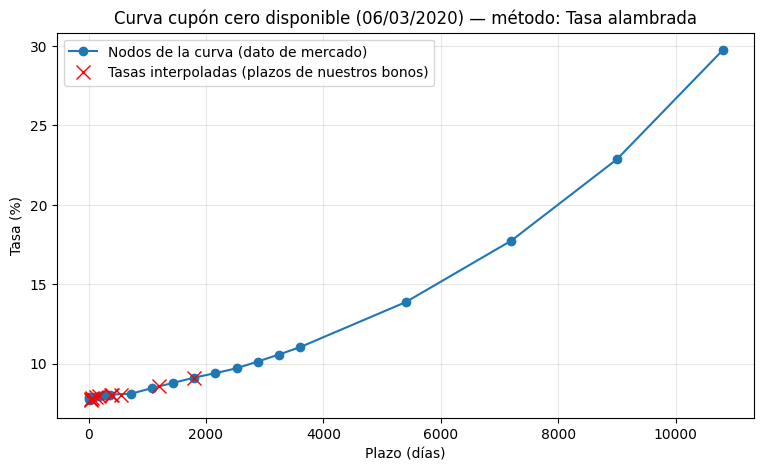

In [10]:
# @title 📈 Curva de tasas vigente y plazos interpolados { display-mode: "both" }
import matplotlib.pyplot as plt

nodos_plot = np.array(nodos_gov[0], dtype=float)
tasas_plot = np.array(x_orig.drop('Date', axis=1).iloc[0], dtype=float)
fecha_curva = x_orig['Date'].iloc[0]

plazos_interp = np.sort(np.unique(np.concatenate([plazos_bcc, plazos_bm])))
if itpl == 1:
    tasas_interp = talamb(nodos_plot, tasas_plot, plazos_interp.astype(float))
else:
    tasas_interp = np.interp(plazos_interp, nodos_plot, tasas_plot, left=tasas_plot[0], right=tasas_plot[-1])

plt.figure(figsize=(9, 5))
plt.plot(nodos_plot, tasas_plot * 100, 'o-', label='Nodos de la curva (dato de mercado)')
plt.plot(plazos_interp, tasas_interp * 100, 'x', markersize=10, color='red',
         label='Tasas interpoladas (plazos de nuestros bonos)')
plt.xlabel('Plazo (d\u00edas)')
plt.ylabel('Tasa (%)')
plt.title(f'Curva cup\u00f3n cero disponible ({fecha_curva:%d/%m/%Y}) \u2014 m\u00e9todo: {metodo_interpolacion}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 💰 Valuación

Ya tenemos parámetros, curvas y funciones de interpolación. Toca aplicar la fórmula de valuación correspondiente a cada instrumento:

| Instrumento | Curva usada | Idea central |
|---|---|---|
| CETES | Cupón cero | Un solo flujo (el nominal) descontado a la tasa del plazo exacto. |
| Bono M (cupón cero) | Cupón cero | Se descuenta **cada cupón por separado**, cada uno a la tasa que le corresponde a su plazo. |
| Bono M (yield) | Yield (TIR) | Se usa **una sola tasa** (la TIR de mercado) y la fórmula cerrada de anualidad de un bono. |
| Bonde D | Cupón cero + spread | Cada cupón es flotante: se calcula con la tasa de fondeo realizada + un spread de mercado, y se descuenta con curva cupón cero + spread. |


## 🧾 CETES o Bonos cupón cero

Un CETE (o cualquier bono cupón cero) promete **un solo pago** al vencimiento: el valor nominal. Su precio es simplemente ese pago, descontado a la tasa correspondiente a su plazo:

$$ V_{CETE} = \frac{N \cdot C}{1 + t_{vp_p} \cdot p/360} $$

Donde:
- $N$: valor nominal del título.
- $C$: número de contratos (la posición; negativo si está en corto).
- $p$: plazo (en días) al vencimiento.
- $t_{vp_p}$: tasa de valor presente (curva cupón cero) interpolada al plazo $p$.


In [11]:
# @title 🧮 Valuación de CETES { display-mode: "both" }
Xvp_bcc = np.zeros((n, len(plazos_bcc)))

for i in range(n):
    if itpl == 0:
        Xvp_bcc[i, :] = np.interp(plazos_bcc, np.array(nodos_gov[0]), np.array(x_orig.drop('Date', axis=1).iloc[i]))
    else:
        Xvp_bcc[i, :] = talamb(np.array(nodos_gov[0]), np.array(x_orig.drop('Date', axis=1).iloc[i]), plazos_bcc)

# Tasas de valor presente interpoladas para el d\u00eda de valuaci\u00f3n (fila 0)
Valoración_cetes = contratos_bcc * nominal_bcc / (1 + Xvp_bcc[0, :] * plazos_bcc / 360)

resumen_cetes = pd.DataFrame({
    'Plazo (d\u00edas)': plazos_bcc,
    'Contratos': contratos_bcc,
    'Tasa interpolada': np.round(Xvp_bcc[0, :] * 100, 4),
    'Valuaci\u00f3n ($)': pd.Series(Valoración_cetes).map('{:,.2f}'.format),
})
resumen_cetes


,Plazo (días),Contratos,Tasa interpolada,Valuación ($)
0,37,22000,7.7538,"218,260.65"
1,40,-29000,7.7687,"-287,518.16"
2,55,29000,7.8233,"286,574.76"
3,120,-46000,7.9294,"-448,154.62"
4,180,10000,7.9883,"96,159.27"


# 📄 Bonos M

Un Bono M paga **cupones periódicos** a tasa fija (aquí, cada `plazocupon_bm` días) y regresa el nominal en el último pago. Para valuarlo con el método de cupón cero, primero necesitamos **reconstruir el calendario completo de flujos** de los 5 bonos de ejemplo: en qué día cae cada cupón, cuánto vale, y cuál es el plazo acumulado (desde hoy) a cada uno de esos pagos.

La siguiente celda hace justo eso — es código de "contabilidad de flujos" (bastante denso en índices), por lo que está colapsado como formulario. Lo importante es el resultado: los vectores `VTplazos` (plazo de cada flujo), `contratosT`, `tasafijaT`, etc., todos alineados uno a uno.


In [12]:
# @title 🗓️ Construcción del calendario de flujos del Bono M { display-mode: "form" }
import numpy as np

# N\u00famero de cupones a pagar por cada uno de los 5 bonos
N = (plazos_bm / plazocupon_bm).astype(int) + 1

# Vectores "aplanados": un elemento por cada flujo (cup\u00f3n) de cada bono
VTplazos = np.zeros((1, int(np.sum(N))))      # plazo acumulado (d\u00edas) de cada flujo
contratosT = np.zeros((1, int(np.sum(N))))    # contratos del bono al que pertenece el flujo
nominalT = np.zeros((1, int(np.sum(N))))      # (no se usa; se deja por compatibilidad)
plazocuponT = np.zeros((1, int(np.sum(N))))   # periodicidad del cup\u00f3n de ese flujo
tasafijaT = np.zeros((1, int(np.sum(N))))     # tasa cup\u00f3n fija de ese flujo
ulNomT = np.zeros((1, int(np.sum(N))))        # nominal que se paga SOLO en el \u00faltimo flujo

# Plazo del primer cup\u00f3n (puede ser "corto" si el bono ya empez\u00f3 a devengar)
plazini = plazos_bm - plazocupon_bm * (N - 1)

for j in range(len(plazos_bm)):
    if j == 0:
        VTplazos[:, 0:int(np.sum(N[0:j+1]))] = np.arange(plazini[j], plazos_bm[j] + plazocupon_bm[j], plazocupon_bm[j])
        contratosT[:, 0:int(np.sum(N[0:j+1]))] = np.arange(contratos_bm[j], contratos_bm[j] + 1)
        plazocuponT[:, 0:int(np.sum(N[0:j+1]))] = plazocupon_bm[j] * np.ones(int(np.sum(N[0:j+1])))
        tasafijaT[:, 0:int(np.sum(N[0:j+1]))] = tfcupon_bm[j] * np.ones(int(np.sum(N[0:j+1])))
        ulNomT[:, N[j]-1] = contratos_bm[j]
    else:
        VTplazos[:, int(np.sum(N[0:j])):int(np.sum(N[0:j+1]))] = np.arange(plazini[j], plazos_bm[j] + plazocupon_bm[j], plazocupon_bm[j])
        contratosT[:, int(np.sum(N[0:j])):int(np.sum(N[0:j+1]))] = np.arange(contratos_bm[j], contratos_bm[j] + 1)
        plazocuponT[:, int(np.sum(N[0:j])):int(np.sum(N[0:j+1]))] = plazocupon_bm[j] * np.ones(int(np.sum(N[j:j+1])))
        tasafijaT[:, int(np.sum(N[0:j])):int(np.sum(N[0:j+1]))] = tfcupon_bm[j] * np.ones(int(np.sum(N[j:j+1])))
        ulNomT[:, int(np.sum(N[0:j+1]))-1] = contratos_bm[j]

# Interpolamos la curva cup\u00f3n cero al plazo de CADA flujo (todos los bonos a la vez)
Xvp = np.zeros((n, VTplazos.shape[1]))
for i in range(n):
    if itpl == 0:
        Xvp[i, :] = np.interp(VTplazos[0, :], np.array(nodos_gov[0]), np.array(x_orig.drop('Date', axis=1).iloc[0]))
    else:
        Xvp[i, :] = talamb(np.array(nodos_gov[0]), np.array(x_orig.drop('Date', axis=1).iloc[0]), VTplazos[0, :])

print("Plazo acumulado de cada flujo (d\u00edas):")
print(VTplazos)
print("\nNominal pagado en cada flujo (solo el \u00faltimo de cada bono es distinto de 0):")
print(ulNomT)


Plazo acumulado de cada flujo (días):
[[  14.  196.  378.   41.  223.  405.    4.  186.  368.  550.  108.  290.
   472.  654.  836. 1018. 1200.  162.  344.  526.  708.  890. 1072. 1254.
  1436. 1618. 1800.]]

Nominal pagado en cada flujo (solo el último de cada bono es distinto de 0):
[[     0.      0.  22000.      0.      0. -29000.      0.      0.      0.
   29000.      0.      0.      0.      0.      0.      0. -46000.      0.
       0.      0.      0.      0.      0.      0.      0.      0.  10000.]]


In [13]:
# @title 🔎 Inspección rápida: plazos calculados { display-mode: "both" }
VTplazos


array([[  14.,  196.,  378.,   41.,  223.,  405.,    4.,  186.,  368.,
         550.,  108.,  290.,  472.,  654.,  836., 1018., 1200.,  162.,
         344.,  526.,  708.,  890., 1072., 1254., 1436., 1618., 1800.]])

## 🧮 Fórmula: Bono a tasa fija, descontado con curva cupón cero

$$ V_{cc}=\sum_{i=1}^{n}\frac{N\cdot C \cdot t_{c}\cdot p_c/360}{(1+t_{vp_{p_i}} \cdot p_i/360)} + \frac{N\cdot C}{(1+t_{vp_{p_n}} \cdot p_n/360)}$$

Donde:
- $V_{cc}$: valor del bono bajo la curva cupón cero (precio sucio).
- $N$: valor nominal del bono.
- $C$: número de contratos.
- $p_{c}$: plazo fijo entre cada pago de cupón.
- $p_{i}$: plazo acumulado (en días) al cupón $i$.
- $t_{c}$: tasa cupón fija.
- $t_{vp_{p_i}}$: tasa de valor presente (curva cupón cero) interpolada al plazo acumulado del cupón $i$.

Es decir: **se descuenta cada cupón por separado** a la tasa que le toca según cuándo ocurre, y al final se le suma el nominal descontado al plazo del último cupón. Aquí solo hay un factor de riesgo subyacente: la curva gubernamental.


In [14]:
# @title 🧮 Función y valuación: Bono M por cupón cero { display-mode: "both" }
import numpy as np
import pandas as pd

def bonoMcccero(contratosT, nominal, tasafijaT, plazocuponT, VTplazos, Xvp, N):
    """
    Valúa uno o varios bonos a tasa fija descontando cada cup\u00f3n con la
    curva cup\u00f3n cero (ver f\u00f3rmula de la celda anterior).
    Todos los vectores vienen "aplanados" (un elemento por flujo); `N`
    indica cu\u00e1ntos flujos le corresponden a cada bono, en orden.
    """
    V0 = np.zeros((1, len(N)))[0]
    V0f = ((((contratosT * tasafijaT * (plazocuponT / 360)) + ulNomT) / (1 + Xvp * VTplazos / 360)) * nominal)[0]
    for j in range(len(N)):
        if j == 0:
            V0[j] = np.sum(V0f[j:N[j]])
        else:
            V0[j] = np.sum(V0f[sum(N[0:j]):sum(N[0:j+1])])
    return V0

V0 = bonoMcccero(contratosT[0], nominal_bm, tasafijaT[0], plazocuponT[0], VTplazos[0], Xvp[0], N)

resumen_bm_cc0 = pd.DataFrame({
    'Plazo (d\u00edas)': plazos_bm,
    'Contratos': contratos_bm,
    'Tasa cup\u00f3n': tfcupon_bm,
    'Valuaci\u00f3n ($)': pd.Series(V0).map('{:,.2f}'.format),
})
resumen_bm_cc0

,Plazo (días),Contratos,Tasa cupón,Valuación ($)
0,378,22000,0.0650,"2,236,455.18"
1,405,-29000,0.0675,"-2,942,426.03"
2,550,29000,0.0700,"2,969,778.38"
3,1200,-46000,0.0750,"-4,643,929.97"
4,1800,10000,0.0780,"1,009,444.86"


## 📄 Bono M — tasa yield

En vez de descontar cada cupón con una tasa distinta, este método usa **una sola tasa** $x$ (la TIR/yield de mercado para ese plazo) y la fórmula cerrada del valor presente de una anualidad más el pago del nominal:

$$ V_{yield} = \left[ N\cdot C\cdot t_c \cdot \frac{p_c}{360}\cdot a(x) + \frac{N\cdot C}{(1+x\cdot p_c/360)^{N}} \right]\cdot (1+x\cdot p_c/360)^{1-\,p_1/p_c} $$

$$ a(x) = \frac{1-(1+x\cdot p_c/360)^{-N}}{p_c\cdot x/360} $$

Donde $N$ es el número de cupones restantes, $p_c$ el plazo fijo de cupón, y $p_1$ el plazo del primer cupón (posiblemente corto). El último factor ajusta el precio al día exacto de valuación cuando ese primer periodo no es completo.

Al usar la misma fecha de valuación y curva, este método y el de cupón cero de la sección anterior deberían dar **resultados muy parecidos** (pequeñas diferencias vienen de que la curva yield y la curva cupón cero no son exactamente la misma cosa).


In [15]:
# @title 📐 Interpolación de la curva yield { display-mode: "form" }
Xvp_bm_yd = np.zeros((n_yd, len(plazos_bm)))

for i in range(n_yd - 1):
    if itpl == 0:
        Xvp_bm_yd[i, :] = np.interp(plazos_bm, np.array(nodos_gov_yd[0]), np.array(x_orig_yd.drop('Date', axis=1).iloc[i]))
    else:
        Xvp_bm_yd[i, :] = talamb(np.array(nodos_gov_yd[0]), np.array(x_orig_yd.drop('Date', axis=1).iloc[i]), plazos_bm)

print("Tasas yield interpoladas para los plazos de nuestros bonos:")
print(plazos_bm)
Xvp_bm_yd


Tasas yield interpoladas para los plazos de nuestros bonos:
[ 378  405  550 1200 1800]


array([[0.07876334, 0.0783339 , 0.07705538, 0.07681561, 0.07673201],
       [0.07890985, 0.07843522, 0.07698535, 0.07688828, 0.07673101],
       [0.07890952, 0.07843444, 0.07698288, 0.0776061 , 0.07755628],
       ...,
       [0.08369606, 0.08336627, 0.0825109 , 0.08647576, 0.08586339],
       [0.08369639, 0.08336685, 0.08251246, 0.08631813, 0.08575924],
       [0.        , 0.        , 0.        , 0.        , 0.        ]])

In [16]:
# @title 🧮 Función y valuación: Bono M por tasa yield { display-mode: "both" }
import numpy as np


Xvp_bm_yd = np.zeros((n_yd, len(plazos_bm)))

for i in range(n_yd-1):
    if itpl == 0:
        # Utiliza interpolación lineal
        Xvp_bm_yd[i, :] = np.interp(plazos_bm,np.array(nodos_gov_yd[0]), np.array(x_orig_yd.drop('Date', axis=1).iloc[i]))
    else:
        # Utiliza la función talamb
        # (Asegúrate de que tengas definida la función talamb)
        Xvp_bm_yd[i, :] = talamb(np.array(nodos_gov_yd[0]), np.array(x_orig_yd.drop('Date', axis=1).iloc[i]), plazos_bm)
print(plazos_bm)
Xvp_bm_yd


def bonoMyield(x, plazos, plazocupon, tfcupon, nominal, contratos):
    """Valúa un bono a tasa fija descontando con una sola tasa yield `x`."""
    N = (plazos / plazocupon).astype(int) + 1
    a = (1 - (1 + x * plazocupon / 360) ** (-N)) / (plazocupon * x / 360)
    p1 = plazos - plazocupon * (N - 1)
    return ((contratos * nominal * tfcupon * plazocupon / 360) * a + (contratos * nominal) / ((1 + x * plazocupon / 360) ** N)) * (1 + x * plazocupon / 360) ** (1 - p1 / plazocupon)

x0 = Xvp_bm_yd[0, :]  # tasas yield vigentes el d\u00eda de valuaci\u00f3n
Valoracion_bonoM_yield = bonoMyield(x0, plazos_bm, plazocupon_bm, tfcupon_bm, nominal_bm, contratos_bm)

resumen_bm_yield = pd.DataFrame({
    'Plazo (d\u00edas)': plazos_bm,
    'Contratos': contratos_bm,
    'Tasa yield': np.round(x0 * 100, 4),
    'Valuaci\u00f3n ($)': pd.Series(Valoracion_bonoM_yield).map('{:,.2f}'.format),
})
resumen_bm_yield


[ 378  405  550 1200 1800]


,Plazo (días),Contratos,Tasa yield,Valuación ($)
0,378,22000,7.8763,"2,236,686.61"
1,405,-29000,7.8334,"-2,943,124.17"
2,550,29000,7.7055,"2,971,368.57"
3,1200,-46000,7.6816,"-4,645,963.96"
4,1800,10000,7.6732,"1,009,443.76"


### 🔍 Comparando ambos métodos

Compara la columna `Valuación ($)` de las dos tablas anteriores: si el método de interpolación, la fecha y las curvas son consistentes entre sí, los resultados de **cupón cero** y **yield** deberían ser prácticamente iguales para el mismo bono. Diferencias grandes suelen indicar que las curvas cupón cero y yield no describen exactamente las mismas condiciones de mercado (son curvas separadas, estimadas de forma independiente).


# 📄 Bondes D

El Bonde D es un bono de **tasa flotante**: en vez de una tasa cupón fija, cada cupón (cada 28 días) se calcula con la **tasa de fondeo bancario realizada** durante ese periodo, más un pequeño ajuste. Esto lo hace un instrumento de bajo riesgo de tasa de interés (su valor casi no cambia cuando cambian las tasas, porque el cupón "se mueve con el mercado").

Para valuarlo necesitamos dos piezas nuevas:

1. **Tasa del cupón en curso** — como el cupón actual ya empezó a devengarse, se combina la tasa de fondeo **ya realizada** (`tf_int`, del inicio del cupón a hoy) con la tasa de fondeo **vigente** (`tf_act`, de hoy al resto del periodo):

$$ t_{cup\acute{o}n} = \left[ \left(1+t_{dev}\cdot\frac{d_{dev}}{360}\right)\cdot\left(1+t_{act}\right)^{\frac{p_c-d_{dev}}{360}\cdot 360} - 1 \right]\cdot\frac{360}{p_c} $$

donde $t_{dev}$ es la tasa geométrica realizada en los $d_{dev}$ días ya transcurridos del cupón, $t_{act}$ es la tasa de fondeo de hoy, y $p_c$ el plazo del cupón (28 días). Los cupones futuros (que aún no empiezan) usan directamente la tasa de fondeo vigente compuesta a 28 días.

2. **Descuento con spread** — el valor presente de cada flujo se calcula con la curva cupón cero **más** una sobretasa/spread de mercado ($t_{st}$), específica para este tipo de instrumento:

$$ V_{f} = \frac{\left(N\cdot C\cdot t_{cup\acute{o}n}\cdot p_c/360\right) + N\cdot C_{\text{(si es el último flujo)}}}{1+(t_{vp_p}+t_{st,p})\cdot p/360} $$

> 🛠️ **Nota de correcciones respecto a la versión original:** al revisar el cuaderno encontramos dos detalles que dejaban la valuación de Bondes D incompleta y los corregimos aquí:
> 1. La rama de interpolación por **tasa alambrada** para las curvas de Bonde D estaba sin implementar (dejaba las tasas en cero). Ahora reutiliza `talamb()`, igual que en CETES y Bono M.
> 2. La función de valuación se estaba llamando con la tasa de fondeo de **hoy** para todos los cupones, en vez de usar el vector `tasafijaT_bd` (que sí distingue el cupón en curso, ya parcialmente devengado, de los cupones futuros). Ahora se usa `tasafijaT_bd`.


In [17]:
# @title 🗓️ Construcción del calendario de flujos y tasas de Bonde D { display-mode: "form" }
m = len(plazos_bdm)
N_bd = (plazos_bdm // plazocupon_bdm) + 1  # n\u00famero de cupones a pagar

VTplazos_bdm = np.zeros(np.sum(N_bd))
contratos_bdmT = np.zeros(np.sum(N_bd))
plazocupon_bdmT = np.zeros(np.sum(N_bd))
tasafijaT_bd = np.zeros(np.sum(N_bd))
ulNomT_bd = np.zeros(np.sum(N_bd))
Xvp_bd = np.zeros((n, len(VTplazos_bdm)))
Xst_bd = np.zeros((n, len(VTplazos_bdm)))

plazini_bd = plazos_bdm - plazocupon_bdm * (N_bd - 1)
ddv = plazocupon_bdm - plazini_bd  # d\u00edas ya transcurridos del cup\u00f3n en curso
tfcupon = np.zeros(m)
tfcupondev = np.zeros(m)
tfcupgen = ((1 + tf_act / 360) ** (plazocupon_bdm[0]) - 1) * 360 / plazocupon_bdm[0]

for j in range(m):
    tfcupondev[j] = ((np.prod(1 + tf_int[0:ddv[j]] / 360) - 1) * 360) / ddv[j]
    tfcupon[j] = (((1 + tfcupondev[j] * ddv[j] / 360) * (1 + tf_act / 360) ** (plazocupon_bdm[0] - ddv[j]) - 1) * 360) / plazocupon_bdm[0]

print("Tasa realizada durante lo que va del cup\u00f3n en curso:", np.round(tfcupondev, 6))
print("Tasa del cup\u00f3n en curso (realizada + vigente):      ", np.round(tfcupon, 6))

for j in range(m):
    sum_N_bd = np.sum(N_bd[:j+1])
    sum_N_bd_prev = np.sum(N_bd[:j]) if j > 0 else 0

    if j == 0:
        VTplazos_bdm[:sum_N_bd] = np.arange(plazini_bd[j], plazos_bdm[j] + 1, plazocupon_bdm[j])
        contratos_bdmT[:sum_N_bd] = contratos_bdm[j]
        plazocupon_bdmT[:sum_N_bd] = plazocupon_bdm[j]
        ulNomT_bd[sum_N_bd - 1] = contratos_bdm[j]
        tasafijaT_bd[0] = tfcupon[j]
        tasafijaT_bd[1:sum_N_bd] = tfcupgen
    else:
        VTplazos_bdm[sum_N_bd_prev:sum_N_bd] = np.arange(plazini_bd[j], plazos_bdm[j] + 1, plazocupon_bdm[j])
        contratos_bdmT[sum_N_bd_prev:sum_N_bd] = contratos_bdm[j]
        plazocupon_bdmT[sum_N_bd_prev:sum_N_bd] = plazocupon_bdm[j]
        tasafijaT_bd[sum_N_bd_prev] = tfcupon[j]
        tasafijaT_bd[sum_N_bd_prev + 1:sum_N_bd] = tfcupgen
        ulNomT_bd[sum_N_bd - 1] = contratos_bdm[j]

# Interpolamos la curva cup\u00f3n cero y la curva de spread al plazo de cada flujo.
# (Antes, la rama de tasa alambrada (itpl == 1) no estaba implementada; ahora
# reutilizamos talamb(), igual que para CETES y Bono M.)
for i in range(n):
    nodos_arr = np.array(nodos, dtype=float)
    nodos3_arr = np.array(nodos3_bd, dtype=float)
    curva_i = np.array(x_orig.drop('Date', axis=1).iloc[i], dtype=float)
    curva3_i = np.array(X3_orig_bd.drop('Date', axis=1).iloc[i], dtype=float)
    if itpl == 0:
        Xvp_bd[i, :] = np.interp(VTplazos_bdm, nodos_arr, curva_i, left=curva_i[0], right=curva_i[-1])
        Xst_bd[i, :] = np.interp(VTplazos_bdm, nodos3_arr, curva3_i, left=curva3_i[0], right=curva3_i[-1])
    else:
        Xvp_bd[i, :] = talamb(nodos_arr, curva_i, VTplazos_bdm)
        Xst_bd[i, :] = talamb(nodos3_arr, curva3_i, VTplazos_bdm)

X2_pr = X2_orig_bd.sort_values('fecha', ascending=False)


Tasa realizada durante lo que va del cupón en curso: [0.110017 0.110383 0.110222 0.109925 0.110446]
Tasa del cupón en curso (realizada + vigente):       [0.109807 0.11016  0.109962 0.109746 0.110315]


In [18]:
# @title 🧮 Función y valuación: Bonde D { display-mode: "both" }
def bondeD(contratosT, nominal, tasafijaT, plazocuponT, VTplazos, Xvp, Xst, N, ulNomT):
    """
    Valúa uno o varios bonos de tasa flotante: cada flujo se calcula con su
    propia tasa de cup\u00f3n (`tasafijaT`, ya distingue el cup\u00f3n en curso de
    los futuros) y se descuenta con la curva cup\u00f3n cero m\u00e1s el spread
    (`Xvp + Xst`).
    """
    V0 = np.zeros(len(N))
    V0f = (((contratosT * tasafijaT * (plazocuponT / 360)) + ulNomT) / (1 + (Xvp + Xst) * VTplazos / 360)) * nominal

    for j in range(len(N)):
        if j == 0:
            V0[j] = np.sum(V0f[:N[j]])
        else:
            V0[j] = np.sum(V0f[np.sum(N[:j]):np.sum(N[:j+1])])

    return V0

# Usamos tasafijaT_bd (tasa por cup\u00f3n) en vez de tf_act (tasa \u00fanica de hoy),
# para que cada flujo se valúe con la tasa que realmente le corresponde.
V0_bd = bondeD(contratos_bdmT, nominal_bdm, tasafijaT_bd, plazocupon_bdmT, VTplazos_bdm, Xvp_bd[0, :], Xst_bd[0, :], N_bd, ulNomT_bd)

resumen_bd = pd.DataFrame({
    'Plazo (d\u00edas)': plazos_bdm,
    'Contratos': contratos_bdm,
    'Valuaci\u00f3n ($)': pd.Series(V0_bd).map('{:,.2f}'.format),
})
resumen_bd


,Plazo (días),Contratos,Valuación ($)
0,358,220,"22,182.88"
1,405,-290,"-29,354.87"
2,550,290,"29,421.83"
3,1200,-460,"-47,302.22"
4,1800,100,"10,517.09"


# 📊 Resumen comparativo

Juntamos los resultados de los tres instrumentos (cuatro, contando los dos métodos del Bono M) en una sola tabla y una gráfica, para comparar de un vistazo el **valor neto de cada posición**.

Recuerda que cada instrumento usa un conjunto de plazos y contratos de ejemplo distinto — no son la misma cartera — así que la comparación es entre el valor neto total de cada método/instrumento, no bono por bono.


,Instrumento,Posición,Plazo (días),Contratos,Valuación ($)
0,CETES,1,37,22000,"218,260.65"
1,CETES,2,40,-29000,"-287,518.16"
2,CETES,3,55,29000,"286,574.76"
3,CETES,4,120,-46000,"-448,154.62"
4,CETES,5,180,10000,"96,159.27"
5,Bono M (cupón cero),1,378,22000,"2,236,455.18"
6,Bono M (cupón cero),2,405,-29000,"-2,942,426.03"
7,Bono M (cupón cero),3,550,29000,"2,969,778.38"
8,Bono M (cupón cero),4,1200,-46000,"-4,643,929.97"
9,Bono M (cupón cero),5,1800,10000,"1,009,444.86"



Valor neto de la posición por instrumento:


/tmp/ipykernel_3720/2182093736.py:34: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(totales.to_frame('Valor neto ($)').applymap('{:,.2f}'.format))


,Valor neto ($)
Instrumento,
CETES,"-134,678.10"
Bono M (cupón cero),"-1,370,677.58"
Bono M (yield),"-1,371,589.19"
Bonde D,"-14,535.29"


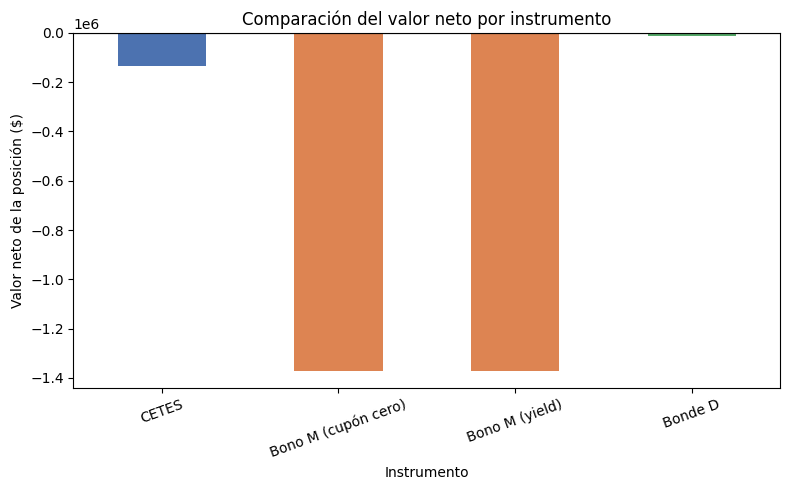

In [19]:
# @title 📊 Tabla y gráfica de resultados { display-mode: "both" }
from IPython.display import display
import matplotlib.pyplot as plt

def tabla_resumen(nombre, plazos, contratos, valuaciones):
    # Formato de la valuación con separador de miles y 2 decimales para la tabla
    return pd.DataFrame({
        'Instrumento': nombre,
        'Posición': np.arange(1, len(plazos) + 1),
        'Plazo (días)': plazos,
        'Contratos': contratos,
        'Valuación ($)': pd.Series(valuaciones).map('{:,.2f}'.format),
    })

resumen = pd.concat([
    tabla_resumen('CETES', plazos_bcc, contratos_bcc, Valoración_cetes),
    tabla_resumen('Bono M (cupón cero)', plazos_bm, contratos_bm, V0),
    tabla_resumen('Bono M (yield)', plazos_bm, contratos_bm, Valoracion_bonoM_yield),
    tabla_resumen('Bonde D', plazos_bdm, contratos_bdm, V0_bd),
], ignore_index=True)

display(resumen)

orden = ['CETES', 'Bono M (cupón cero)', 'Bono M (yield)', 'Bonde D']

# Convertir 'Valuación ($)' a numérico para poder realizar la suma y el gráfico
# Se remueven las comas y se convierte a float
resumen_numeric = resumen.copy()
resumen_numeric['Valuación ($)'] = resumen_numeric['Valuación ($)'].str.replace(',', '').astype(float)

totales = resumen_numeric.groupby('Instrumento')['Valuación ($)'].sum().reindex(orden)
print("\nValor neto de la posición por instrumento:")
# Formatear el DataFrame de totales para su visualización
display(totales.to_frame('Valor neto ($)').applymap('{:,.2f}'.format))

plt.figure(figsize=(8, 5))
totales.plot(kind='bar', color=['#4C72B0', '#DD8452', '#DD8452', '#55A868'])
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Valor neto de la posición ($)')
plt.title('Comparación del valor neto por instrumento')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# ✅ Glosario y para seguir practicando

### Glosario rápido
- **Nominal ($N$):** el monto que se paga al vencimiento de un bono (por unidad, sin contar contratos).
- **Contratos ($C$):** el tamaño de la posición; negativo significa que estamos "cortos" (vendidos).
- **Cupón:** pago periódico de intereses antes del vencimiento.
- **Curva cupón cero:** tasas de descuento puras por plazo, sin cupones de por medio.
- **Curva yield:** la TIR de mercado para un bono cuponado de cierto plazo.
- **Tasa alambrada:** método de interpolación consistente con tasas forward, estándar en el mercado mexicano.
- **Tasa de fondeo:** tasa de referencia de muy corto plazo (overnight) a la que se indexan los cupones de instrumentos de tasa flotante como el Bonde D.
- **Spread/sobretasa:** ajuste adicional sobre la curva base para reflejar riesgo/liquidez propios del instrumento.

### 🧪 Ejercicios sugeridos
1. Cambia `fecha_valuacion` y observa cómo cambia la curva graficada (recuerda la nota sobre qué fecha usa cada archivo).
2. Compara los resultados con `metodo_interpolacion = "Interpolación lineal"` vs. `"Tasa alambrada"`. ¿Qué tan grande es la diferencia?
3. Modifica los `plazos_bm` o `tfcupon_bm` de un bono y recalcula: ¿el precio sube o baja? ¿Tiene sentido con lo que sabes de duración y tasas?
4. Agrega una sexta posición a cualquiera de los instrumentos (edita los campos de formulario para que las listas tengan 6 elementos en vez de 5).
5. ¿Por qué el valor del Bonde D cambia tan poco frente a movimientos de tasas, comparado con el Bono M? Relaciona tu respuesta con el concepto de duración.

** Nota

6.  Hacer la valuación a nivel portafolio del BPA182
UDI, tasa_guber.txt, tasa_real.txt, sobretasa_BPA.txt (3 pts extras)


###Ejercicio Sugerido 1
Se cambio la fecha al 16/01/2023 y observamos que la curva graficada y las valuaciones de CETES y Bono M no cambiaron con respecto a la fecha original(10/03/2023), esto porque la celda de carga de datos siempre toma la fila más reciente disponible para construir la curva y valuar, sin filtrar por lo tanto el campo de fecha de valuación no tiene efecto real sobre cetes ni sobre bono M, solo impacta la valuación del Bonde D puesto que su tasa de fondeo si se busca explicitamente para la fecha.



###Ejercicio Sugerido 2
Primero volvimos a usar la fecha inicial del 10/03/2023


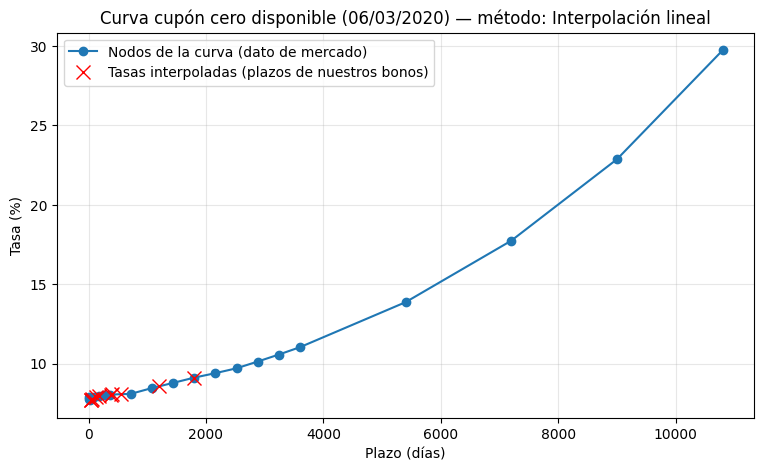

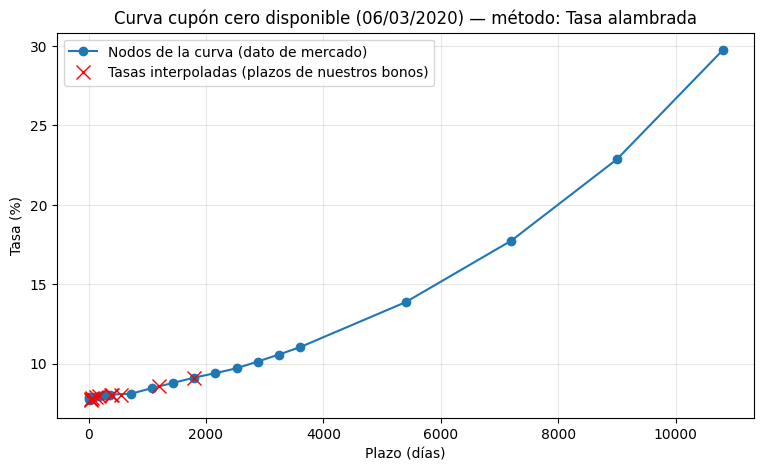

Al comparar las dos gráficas, la curva azul es idéntica en ambos casos lo que tiene sentido, porque el método de interpolación no cambia los datos de mercado, solo la forma de leer entre ellos. La diferencia está en las "x" rojas, en ambas gráficas se agrupan casi en el mismo lugar, muy pegadas al primer tramo de la curva es decir en plazos cortos, menores a 2000 días, donde la curva sube rápido de 8% a 9.5%. Visualmente casi no se nota diferencia entre los dos métodos porque todos los plazos de tus bonos caen relativamente cerca de los primeros nodos

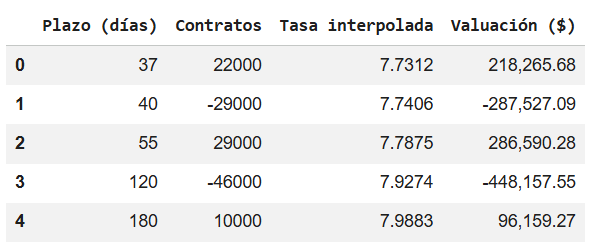

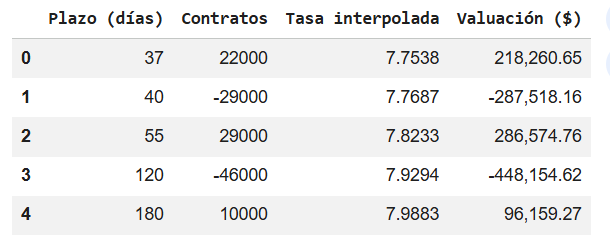

Diferencia total de la posición: -$8.69 , una variación de apenas 0.006%. Es el instrumento con la diferencia más chica de los cuatro, porque son los plazos más cortos (37 a 180 días)

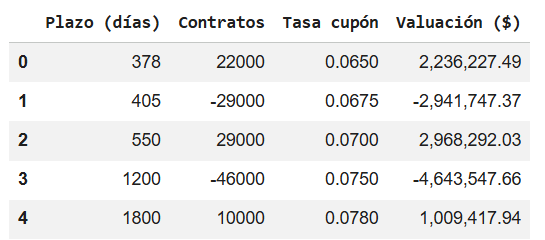

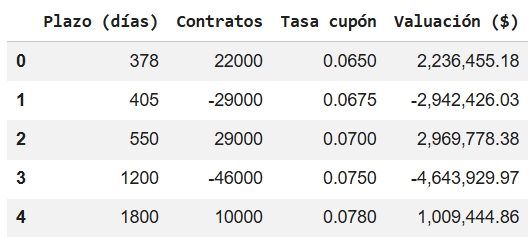

Diferencia neta de la posición de aproximadamente el 0.05%. Es el instrumento con la mayor diferencia en pesos de los cuatro. El plazo de 550 días es el que más se mueve ($1,486), porque cae más lejos de los nodos vecinos de la curva que el resto de los plazos de este bono.

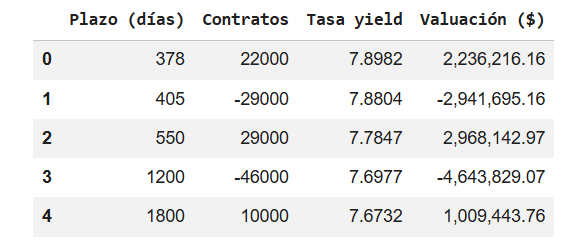

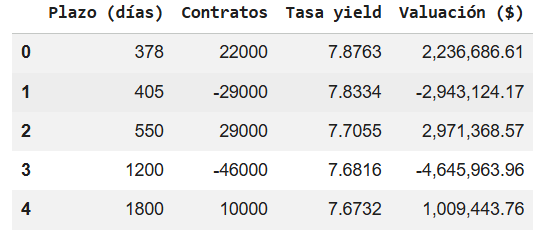

Diferencia neta de la posición: +132.15 (-1,371,721.34 a -1,371,589.19). Aunque en cada bono individual el método yield muestra oscilaciones más grandes que el de cupón cero, esas diferencias se cancelan parcialmente entre posiciones largas y cortas, dejando una diferencia menor a la del método de cupón cero.

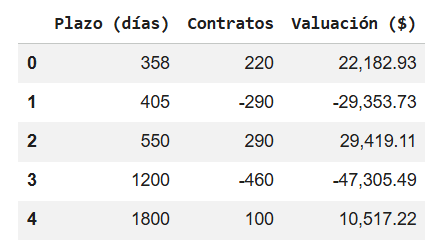

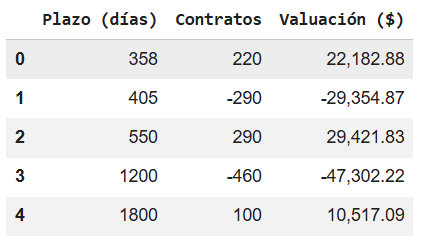

Diferencia neta de la posición: +4.67 (de -14,539.96 a -14,535.29). Es prácticamente insensible al método de interpolación pues al ser un flotante que se resetea cada 28 días, su valor está determinado casi enteramente por la tasa de fondeo del cupón en curso, y la curva cupón cero solo se usa para descontar , por lo que el método de interpolación tiene un impacto todavía menor que en los bonos de tasa fija.

###Ejercicio Sugerido 6
6.  Hacer la valuación a nivel portafolio del BPA182
UDI, tasa_guber.txt, tasa_real.txt, sobretasa_BPA.txt



El BPA182 (Bono de Protección al Ahorro a 182 días) es un instrumento del IPAB
denominado en UDIs. Es estructuralmente parecido al Bono M (cupón real fijo
cada 182 días + nominal al vencimiento), pero:

1. Sus flujos están en UDIs; para pasarlos a pesos se multiplican por el
   valor de la UDI vigente en la fecha de valuación.
2. Se descuenta con la curva de tasa real más una sobretasa propia del BPA.

Dado que la información que se maneja no es a dia de hoy optamos por construir una simulación para los archivos tasa_real.txt, sobretasa_BPA.txt y UDI.txt con supuestos razonables.

In [20]:
#Creamos los archivos que usaremos para el ejercicio
import numpy as np
import pandas as pd

#Planteamos los plazos típicos que maneja el mercado de deuda mexicano
nodos_ejemplo = [1, 7, 28, 91, 182, 364, 728, 1092, 1456, 1820]  # días

#Generamos 260 fechas (aprox 1 año hábil) terminando en la fecha de
# valuación, para simular un histórico de la curva día a día,
# igual que trae tasa_guber.txt.

fechas_ej = pd.date_range(end=fval, periods=260, freq='D')

np.random.seed(0)

#Simulamos una curva real tal que las tasas reales de referencia por nodo estan entre
#1.0% y 2.3%, además se le agrega una desviavión estandar de 0.05% a cada fecha para
#simular variación diaria en la curva lo que ocurriría en un mercado real

base_real = np.array([0.010, 0.012, 0.015, 0.017, 0.018, 0.019, 0.020, 0.021, 0.022, 0.023])
with open('tasa_real.txt', 'w') as fp:
    fp.write('\t'.join(['0'] + [str(n) for n in nodos_ejemplo]) + '\n')
    for f in fechas_ej:
        ruido = np.random.normal(0, 0.0005, len(nodos_ejemplo))
        fila = [int(f.strftime('%Y%m%d'))] + list(np.round(base_real + ruido, 6))
        fp.write('\t'.join(str(x) for x in fila) + '\n')

#Simulación de la sobretasa BPA, el Spread que se suma a la curva real para descontar el
# BPA182, esta entre 0.10% y 0.30% (spread crediticio pequeño, razonable
# para un instrumento de bajo riesgo como el BPA).

base_st = np.array([0.0010, 0.0012, 0.0015, 0.0018, 0.0020, 0.0022, 0.0025, 0.0027, 0.0028, 0.0030])
with open('sobretasa_BPA.txt', 'w') as fp:
    fp.write('\t'.join(['0'] + [str(n) for n in nodos_ejemplo]) + '\n')
    for f in fechas_ej:
        ruido = np.random.normal(0, 0.0001, len(nodos_ejemplo))
        fila = [int(f.strftime('%Y%m%d'))] + list(np.round(base_st + ruido, 6))
        fp.write('\t'.join(str(x) for x in fila) + '\n')

#Simulación del valor de la UDI, primero partimos de un valor incial del la UDI
#7.70 pesos y lo hacemos crecer geométricamente un 0.015% diario que es como
# se mueve la UDI en la realidad
udi_inicial = 7.70
valores_udi = udi_inicial * (1 + 0.00015) ** np.arange(len(fechas_ej))
with open('UDI.txt', 'w') as fp:
    fp.write('fecha\tudi\n')
    for f, v in zip(fechas_ej, valores_udi):
        fp.write(f"{int(f.strftime('%Y%m%d'))}\t{v:.6f}\n")

btasareal_bpa = "tasa_real.txt"
btasastbpa = "sobretasa_BPA.txt"
budi = "UDI.txt"
print("Insumos simulados generados: tasa_real.txt, sobretasa_BPA.txt, UDI.txt")

Insumos simulados generados: tasa_real.txt, sobretasa_BPA.txt, UDI.txt


In [22]:
# @title Parámetros — BPA182
# Planteamos una tasa real fija de cada posición en decimal
tfcupon_bpa = [0.0035, 0.004, 0.0045, 0.005, 0.0055]  # @param {type:"raw"}
plazos_bpa = [182, 364, 546, 910, 1274]  # @param {type:"raw"}
plazocupon_bpa = [182, 182, 182, 182, 182]  # @param {type:"raw"}
contratos_bpa = [15000, -18000, 20000, -12000, 9000]  # @param {type:"raw"}
nominal_bpa = 100  # @param {type:"number"}  (nominal en UDIs)

#Convertimos las listas anteriores a arreglos de NumPy para poder operar
#con ellas de forma vectorizada
tfcupon_bpa = np.array(tfcupon_bpa)
plazos_bpa = np.array(plazos_bpa)
plazocupon_bpa = np.array(plazocupon_bpa)
contratos_bpa = np.array(contratos_bpa)

In [23]:
# @title Carga de la curva real, sobretasa BPA y valor de la UDI { display-mode: "form" }
data_r = pd.read_table(btasareal_bpa, sep="\t", header=None)
n_r = data_r.shape[0]; m_r = data_r.shape[1]
Xr_orig = pd.DataFrame(data_r.iloc[1:n_r, 1:m_r], dtype=float)
Xr_orig['Date'] = pd.to_datetime(data_r.iloc[1:n_r, 0], format='%Y%m%d')
nodos_r = np.array(data_r.iloc[0, 1:m_r], dtype=float)

data_stbpa = pd.read_table(btasastbpa, sep="\t", header=None)
n_stbpa = data_stbpa.shape[0]; m_stbpa = data_stbpa.shape[1]
Xst_bpa_orig = pd.DataFrame(data_stbpa.iloc[1:n_stbpa, 1:m_stbpa], dtype=float)
Xst_bpa_orig['Date'] = pd.to_datetime(data_stbpa.iloc[1:n_stbpa, 0], format='%Y%m%d')
nodos_stbpa = np.array(data_stbpa.iloc[0, 1:m_stbpa], dtype=float)

data_udi = pd.read_table(budi, sep="\t", header=None)
n_udi = data_udi.shape[0]
X_udi_bd = data_udi.iloc[1:n_udi, 0:2].copy()
X_udi_bd[0] = pd.to_datetime(X_udi_bd[0], format='%Y%m%d')
X_udi_bd[1] = X_udi_bd[1].astype(float)
X_udi_bd = X_udi_bd.rename(columns={0: 'fecha', 1: 'udi'}).sort_values('fecha')
udi_fval = pd.merge_asof(pd.DataFrame({'fecha': [fval]}), X_udi_bd, on='fecha', direction='backward')['udi'].iloc[0]

print(f"Valor de la UDI simulado en {fval:%d/%m/%Y}: {udi_fval:.6f} pesos/UDI")

Valor de la UDI simulado en 10/03/2023: 8.005009 pesos/UDI


In [25]:
# @title Calendario de flujos del BPA182 { display-mode: "form" }
N_bpa = (plazos_bpa / plazocupon_bpa).astype(int) + 1

#Planteamos los arreglos donde vamos aplanar los flujos de las 5 posiciones
#en un solo vector largo para poder vectorizar el calculo después
VTplazos_bpa = np.zeros((1, int(np.sum(N_bpa))))
contratosT_bpa = np.zeros((1, int(np.sum(N_bpa))))
plazocuponT_bpa = np.zeros((1, int(np.sum(N_bpa))))
tasafijaT_bpa = np.zeros((1, int(np.sum(N_bpa))))
ulNomT_bpa = np.zeros((1, int(np.sum(N_bpa))))

#El plazo del primer cupón de cada posición se calcula hacia atras desde el plazo
#total, restando lso cupones completos que ya pasaron

plazini_bpa = plazos_bpa - plazocupon_bpa * (N_bpa - 1)

#Recorremos cada una de las 5 posiciones para desenrollar su calendario de flujos dentro de los
#arreglos grandes de arriba
for j in range(len(plazos_bpa)):
    idx = slice(0, int(np.sum(N_bpa[0:j+1]))) if j == 0 else slice(int(np.sum(N_bpa[0:j])), int(np.sum(N_bpa[0:j+1])))
    VTplazos_bpa[:, idx] = np.arange(plazini_bpa[j], plazos_bpa[j] + plazocupon_bpa[j], plazocupon_bpa[j])
    contratosT_bpa[:, idx] = contratos_bpa[j]
    plazocuponT_bpa[:, idx] = plazocupon_bpa[j]
    tasafijaT_bpa[:, idx] = tfcupon_bpa[j]
    ulNomT_bpa[:, int(np.sum(N_bpa[0:j+1])) - 1] = contratos_bpa[j]

#Tomamos la curva vigente "hoy" (dado que simulamos es la pprimer fila de cada archivo)
#tanto de la curva real como de la sobretasa BPA quitando la columna de fecha
curva_r_hoy = np.array(Xr_orig.drop('Date', axis=1).iloc[0], dtype=float)
curva_st_hoy = np.array(Xst_bpa_orig.drop('Date', axis=1).iloc[0], dtype=float)

# Interpolamos ambas curvas al plazo exacto de cada flujo
if itpl == 0:
    Xvp_bpa = np.interp(VTplazos_bpa[0, :], nodos_r, curva_r_hoy, left=curva_r_hoy[0], right=curva_r_hoy[-1])
    Xst_bpa = np.interp(VTplazos_bpa[0, :], nodos_stbpa, curva_st_hoy, left=curva_st_hoy[0], right=curva_st_hoy[-1])
else:
    Xvp_bpa = talamb(nodos_r, curva_r_hoy, VTplazos_bpa[0, :])
    Xst_bpa = talamb(nodos_stbpa, curva_st_hoy, VTplazos_bpa[0, :])

/tmp/ipykernel_3720/3100592228.py:45: RuntimeWarning: divide by zero encountered in divide
  ((((1 + TL_interp * nodos_i_plus_1 / 360) / (1 + TC_interp * nodos_i / 360)) **


In [26]:
# @title Valuación BPA182 { display-mode: "both" }
#Valuamos el BPA182 flujo por flujo y luego sumamos los flujos que le corresponden
#a cada posición donde el resultado ya queda en UDIS
def bpa182(contratosT, nominal, tasafijaT, plazocuponT, VTplazos, Xvp, Xst, N, ulNomT):
  #Calculamos el valor presente de cada flujo
    V0 = np.zeros(len(N))
    # V0f trae todos los flujos de las 5 posiciones "aplanados" en un
    # solo vector
    V0f = (((contratosT * tasafijaT * (plazocuponT / 360)) + ulNomT)
           / (1 + (Xvp + Xst) * VTplazos / 360)) * nominal
    for j in range(len(N)):
        V0[j] = np.sum(V0f[:N[j]]) if j == 0 else np.sum(V0f[np.sum(N[:j]):np.sum(N[:j+1])])
    return V0
# Valuamos las 5 posiciones del BPA182, el resultado está en UDIs
V0_bpa_udi = bpa182(contratosT_bpa[0], nominal_bpa, tasafijaT_bpa[0], plazocuponT_bpa[0],
                     VTplazos_bpa[0], Xvp_bpa, Xst_bpa, N_bpa, ulNomT_bpa[0])

# Convertimos cada posición de UDIs a pesos
V0_bpa_pesos = V0_bpa_udi * udi_fval

#Creamos una tabla resumen
resumen_bpa = pd.DataFrame({
    'Plazo (días)': plazos_bpa, 'Contratos': contratos_bpa, 'Tasa cupón real': tfcupon_bpa,
    'Valuación (UDIs)': pd.Series(V0_bpa_udi).map('{:,.4f}'.format),
    'Valuación ($)': pd.Series(V0_bpa_pesos).map('{:,.2f}'.format),
})
resumen_bpa

,Plazo (días),Contratos,Tasa cupón real,Valuación (UDIs),Valuación ($)
0,182,15000,0.0035,"1,489,585.2269","11,924,143.15"
1,364,-18000,0.0040,"-1,774,042.1258","-14,201,223.18"
2,546,20000,0.0045,"1,953,084.8041","15,634,461.43"
3,910,-12000,0.0050,"-1,150,798.7941","-9,212,154.70"
4,1274,9000,0.0055,"848,190.6107","6,789,773.47"


In [27]:
# @title Valor neto del portafolio de BPA182 { display-mode: "both" }
# Sumamos el valor de las 5 posiciones
valor_portafolio_bpa_udi = np.sum(V0_bpa_udi)
valor_portafolio_bpa_pesos = np.sum(V0_bpa_pesos)
# Mostramos el resultado en las dos unidades
print(f"Valor neto del portafolio de BPA182: {valor_portafolio_bpa_udi:,.4f} UDIs")
print(f"Valor neto del portafolio de BPA182: ${valor_portafolio_bpa_pesos:,.2f} pesos")

Valor neto del portafolio de BPA182: 1,366,019.7218 UDIs
Valor neto del portafolio de BPA182: $10,935,000.17 pesos
